# Progressive Damage of an Open-Hole Tension Plate

NB1&ndash;3 verified Abaqus's built-in Hashin damage model on a single shell element and used
it to run Monte Carlo campaigns cheap enough to repeat hundreds of times. NB4 and NB5 stayed
purely analytical, propagating uncertainty and computing Sobol' indices through closed-form
maps of that single-element model &mdash; no Abaqus job ran in either notebook. NB5 closed with
a promise: move to a genuinely heavier deterministic model, run it once, and measure honestly
what it costs, because that cost is what makes the case for NB7's surrogate.

This notebook is that model: an **open-hole tension (OHT) plate** &mdash; a square, multi-ply
composite laminate with a circular hole through its center, loaded in uniaxial tension until it
fails. It reproduces the benchmark of
[Thapa et al. (2021)](https://doi.org/10.1007/s00158-020-02690-5), itself a reproduction of the
experiment and mesh-sensitivity study of
[Liu et al. (2010)](https://doi.org/10.1177/0021998310372466), for the **deterministic, in-plane
uniaxial tension** case only. Two things are deliberately different from both references, and
you'll build up the reasoning behind each from scratch in Parts 2&ndash;5:

- **Energy-based linear softening, not sudden degradation.** Neither reference paper uses a
  fracture energy at all &mdash; Thapa knocks a failed ply's stiffness down to 1% of its original
  value the instant it fails; Liu releases nodal forces in a custom finite element. Neither has
  a length scale, which is exactly why Liu's own predicted strength slides from 415.1 MPa to
  366.3 MPa as his mesh refines (his Table 2). You already met fracture energy and linear
  softening in NB1, on a single element where a mesh-size question could not even be asked.
  Here it can, and Part 4 asks it.
- **No Puck.** Both reference papers use, or discuss, the Puck failure criterion. Abaqus's
  built-in composite damage model does not implement it &mdash; only Hashin. Reproducing Puck
  would need a custom Fortran subroutine, which this environment cannot currently compile. This
  notebook uses Hashin throughout, and compares its answer against Liu's own Hashin column in
  Part 9, rather than pretending to reproduce Puck.

## Learning objectives

By the end of this notebook, you should be able to:

- Explain what a ply stacking sequence does, and why `[45/0/-45/90]s` is *symmetric*,
  *balanced*, and *quasi-isotropic* &mdash; and what each of those properties buys you.
- Explain why a hole concentrates stress, and why a notched strength is a structural property,
  not a material one.
- Explain why a fracture energy needs a companion length scale to give a mesh-independent
  answer once damage can localize into more than one element, and compute that length-scale
  ceiling for a given material.
- Explain what damage stabilization does to an implicit solver, and how to check that it did
  not buy convergence at the cost of a wrong answer.
- Read a progressive damage sequence (which ply, which mode, in what order) directly off a
  laminate's field output, and explain *why* that sequence happens physically.
- State, from the measured cost of a single solve, why running this model dozens or hundreds of
  times &mdash; the way NB2's and NB3's Monte Carlo campaigns ran the single-element model &mdash;
  is not a realistic way to do uncertainty quantification here.

## Part 1 &ndash; The benchmark

### The specimen

Both reference papers use the same specimen: a square, quasi-isotropic carbon/epoxy laminate
with a central circular hole, pulled in tension along one axis.

| Quantity | Value |
|---|---|
| Plate | 76.2 mm &times; 76.2 mm square |
| Hole diameter | 19.05 mm (centered) |
| Stacking sequence | $[45/0/-45/90]_s$ &mdash; 8 plies |
| Ply thickness | 0.125 mm each &rarr; laminate thickness 1.0 mm |
| Material | IM7/5250-4 carbon fiber / bismaleimide (BMI) |

The $[\cdot]_s$ notation means the 4-ply sequence $45/0/-45/90$ is repeated in mirror image
through the thickness: $45/0/-45/90/90/-45/0/45$. Part 2 explains why that mirroring, and this
particular choice of angles, matters.

**Ply angle convention.** "0&deg;" means the ply's fibers run *along the loading direction*.
This is Liu's convention (his Fig. 1), and the one Thapa's own validation run adopts. It matters
because Thapa's *later*, stochastic runs switch to a different convention (0&deg; transverse to
the load) &mdash; a detail easy to miss if you only skim the abstract. This notebook uses Liu's
convention throughout, and the script that builds the model documents exactly where that
convention enters the geometry.

### Material properties

All properties below are Liu et al. (2010)'s Table 1, in this repository's mm/N/MPa unit
system:

| Property | Value | Meaning |
|---|---|---|
| $E_1$ | 172400 MPa | fiber-direction modulus |
| $E_2$ | 10300 MPa | transverse modulus |
| $\nu_{12}$ | 0.32 | major Poisson's ratio |
| $G_{12}=G_{13}$ | 5520 MPa | in-plane / interlaminar shear modulus |
| $G_{23}$ | 3450 MPa | transverse shear modulus |
| $X_T$ | 2826.5 MPa | longitudinal (fiber) tensile strength |
| $X_C$ | 1620 MPa | longitudinal compressive strength |
| $Y_T$ | 65.5 MPa | transverse (matrix) tensile strength |
| $Y_C$ | 248 MPa | transverse compressive strength |
| $S_L=S_T$ | 122 MPa | shear strength |

**A discrepancy worth noticing.** Thapa's own Table 1 lists $X_T=2526.5$ MPa &mdash; every other
number in it matches Liu's table exactly, digit for digit, which makes 2526.5 almost certainly a
transcription slip (2826.5 with two digits swapped) rather than a deliberately different value.
This notebook uses Liu's **2826.5 MPa**. It's a small thing, but it's exactly the kind of
discrepancy a careful reader of the literature should learn to notice rather than copy blindly
&mdash; every notebook in this series traces its numbers to a specific source for this reason.

### What neither paper gives you: a fracture energy

Both papers use strength-based failure criteria with no fracture energy at all. Thapa's
degradation is instantaneous (a failed ply's stiffness drops to 1% of its original value on the
very next increment); Liu's is a nodal-force release built into a custom element formulation.
**Neither has a length scale**, and Part 4 explains in detail why that matters and what it costs
Liu's own mesh-sensitivity study.

This notebook instead uses Abaqus's built-in **energy-based linear softening**, exactly the
mechanism NB1 introduced on a single element. No published fracture energy exists for
IM7/5250-4 (the actual benchmark material) &mdash; so, flagged explicitly as a pedagogical
substitution, this notebook borrows *measured* fracture energies for **IM7-8552**, a different
but closely related material (same IM7 fiber, a toughened epoxy instead of 5250-4's BMI resin),
from [Camanho, Maimi & Davila (2007)](https://doi.org/10.1016/j.compscitech.2007.02.005) &mdash;
itself an open-hole-tension continuum-damage study, which keeps the substitution as close as
practical:

| Abaqus input | Value | Source |
|---|---|---|
| $G_{fT}$ | 81.5 N/mm | Table 5, $G_{1+}$ |
| $G_{fC}$ | 106.3 N/mm | Table 5, $G_{1-}$ |
| $G_{mT}$ | 0.2774 N/mm | Table 3, $G_{2+}$ |
| $G_{mC}$ | 0.7879 N/mm | Table 3, $G_6$ (mode-II shear &mdash; see the note below) |

($1\ \mathrm{kJ/m^2} = 1\ \mathrm{N/mm}$ exactly, so these numbers carry over into this
repository's unit system with no conversion arithmetic needed.)

One more flagged simplification: Abaqus's matrix-*compression* damage mode is driven by shear,
not by pure transverse compression, and Camanho et al. never measured a separate transverse-
compression fracture energy ($G_{2-}$) &mdash; so $G_{mC}$ above is fed their measured mode-II
(shear) energy $G_6$ instead, which is the quantity that actually governs this mode in Abaqus's
formulation.

### The experiment, and what "success" looks like

Liu reports an experimental open-hole tension strength of **397.1 MPa** (from Sihn, private
communication), and his own five failure theories, run on four meshes, bracket that number from
above and below (his Table 2). Thapa's Nastran/Puck/sudden-degradation model predicts
**388.91 MPa**. This notebook is not trying to match either number exactly &mdash; it is using a
genuinely different damage model (Hashin, not Puck; energy-based softening, not sudden
degradation or nodal-force release) on a genuinely different solver. Part 9 compares this
notebook's own prediction against both, and against Liu's own **Hashin** column specifically
(since that is the like-for-like comparison), and discusses the gap physically rather than
tuning anything to close it.

## Part 2 &ndash; From one ply to a laminate

Every model in NB1&ndash;3 was a single ply: one sheet of unidirectional fiber-reinforced
material, its fibers all running one direction. A real structural part is almost never built
that way, because a single ply is strong along its fibers and weak across them ($X_T \gg Y_T$:
2826.5 MPa versus 65.5 MPa above, a factor of 43). **Stacking plies at different angles** is
how a laminate gets meaningful strength and stiffness in more than one direction.

### What a stacking sequence notation means

$[45/0/-45/90]_s$ lists the ply angles from one face of the laminate to the plane of symmetry;
the subscript $s$ says to mirror that list to get the rest of the laminate. So the full,
8-ply stack, top to bottom, is:

$$45^\circ,\ 0^\circ,\ -45^\circ,\ 90^\circ,\ 90^\circ,\ -45^\circ,\ 0^\circ,\ 45^\circ$$

Three properties of this particular choice matter for everything that follows, and each has a
concrete physical payoff:

- **Symmetric** (mirror-image about the mid-plane): this makes the laminate's
  bending-extension coupling matrix $B$ exactly zero. In-plane loading (like this notebook's
  uniaxial tension) then produces *pure membrane stretching, with no bending at all* &mdash;
  a claim Part 6 turns into a concrete, checkable boundary-condition argument, and one you
  will directly verify against this model's own reaction forces in Part 7.
- **Balanced** (every $+\theta$ ply is matched by a $-\theta$ ply of the same thickness): this
  makes the shear-extension coupling terms $A_{16}=A_{26}=0$. A pure axial stretch then produces
  no in-plane shearing of the laminate as a whole.
- **Quasi-isotropic**: with four evenly spaced angles ($0,45,90,-45$, each equally represented),
  the laminate's in-plane extensional stiffness is *the same in every direction* &mdash;
  numerically identical to an isotropic material's, even though every individual ply is
  strongly directional. You'll compute this laminate's isotropic-equivalent modulus directly
  from ply properties in the code cell below, and check it against the model's own elastic
  response in Part 6.

None of this makes the laminate uniform through its thickness, though &mdash; and that's the
point of the next bit.

### The one fact that explains everything later

**Under one uniform laminate strain, every ply sees a different stress**, because each ply's
own stiffness in the loading direction depends on its own fiber angle relative to that
direction. A $0^\circ$ ply (fibers along the load) carries load almost entirely through its
stiff, strong fiber direction; a $90^\circ$ ply (fibers transverse to the load) is being
stretched almost entirely *across* its fibers, into its weak, low-strength matrix direction.
Hold onto this &mdash; Part 7 is going to use it to explain, from first principles, exactly
which ply fails first, in exactly which mode, and why.

### Modeling this in Abaqus: composite shell sections and section points

A single-ply model (NB1) used a `HomogeneousShellSection`: one thickness, one material, one
orientation. This model instead needs a `CompositeShellSection`: a stack of `SectionLayer`
entries, each with its own thickness (0.125 mm), material, and orientation angle. Abaqus then
samples stress and strain at a handful of **section points** through each ply's own thickness
(this model uses 3 per ply, the Simpson-integration default, enough to resolve a linear
variation of stress through an individual ply's thickness) &mdash; so a field-output quantity
like `DAMAGEMT` isn't one number per element, it's one number *per element, per section point*,
and Part 6 shows exactly how the script keeps those numbers straight.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# This notebook's own helper modules (none of which touch Abaqus) live in ../scripts, same
# convention as every previous notebook.
sys.path.insert(0, "../scripts")

RUNS_DIR = Path("../runs/nb06")
RUNS_DIR.mkdir(parents=True, exist_ok=True)

# --------------------------------------------------------------------------------------------
# Classical laminate theory, just far enough to get one number: the quasi-isotropic in-plane
# modulus of [45/0/-45/90]s, via the Tsai-Pagano stiffness invariants. This does not depend on
# ply angle order or which direction you call "0" -- a genuinely quasi-isotropic laminate's
# extensional modulus is the same in every in-plane direction, which is exactly the property
# being checked here (and used again in Part 6 as an elastic sanity check on the real model).
# --------------------------------------------------------------------------------------------
E1, E2, nu12, G12 = 172400.0, 10300.0, 0.32, 5520.0  # MPa; Liu et al. (2010) Table 1
nu21 = nu12 * E2 / E1  # minor Poisson's ratio, from reciprocity (nu12/E1 = nu21/E2)

denom = 1 - nu12 * nu21
Q11 = E1 / denom  # reduced stiffness of a UD ply along its own fiber direction
Q22 = E2 / denom  # ... and transverse to it
Q12 = nu12 * Q22
Q66 = G12

U1 = (3 * Q11 + 3 * Q22 + 2 * Q12 + 4 * Q66) / 8.0  # Tsai-Pagano invariants: U1, U4 are the
U4 = (Q11 + Q22 + 6 * Q12 - 4 * Q66) / 8.0           # two that survive angle-averaging for a
                                                       # laminate with evenly spaced angles
E_QI = U1 - U4 ** 2 / U1  # the quasi-isotropic laminate's isotropic-equivalent modulus

t_laminate = 1.0  # mm, total laminate thickness (8 plies x 0.125 mm)
print(f"Quasi-isotropic in-plane modulus E_QI = {E_QI:,.1f} MPa = {E_QI / 1000:.2f} GPa")
print(f"Unnotched axial stiffness (no hole) k = E_QI * t = {E_QI * t_laminate:,.1f} N/mm")

Quasi-isotropic in-plane modulus E_QI = 65,414.8 MPa = 65.41 GPa
Unnotched axial stiffness (no hole) k = E_QI * t = 65,414.8 N/mm


This is the laminate's *unnotched* stiffness &mdash; the number you'd get
without the hole. Part 6 uses it as a hand-check on the real model's own elastic response,
before any damage is switched on.

## Part 3 &ndash; What a hole does

### Stress concentration

Cut a hole in a plate under tension and the load that used to pass straight through the
material the hole now occupies has to detour around it. That detour crowds the load lines
together at the sides of the hole, so the local stress there is higher than the average
("remote" or "gross-section") stress far away &mdash; a **stress concentration**. For an
isotropic plate with a small circular hole, the classical elasticity result is a factor of 3;
a finite-width, anisotropic, multi-ply laminate like this one is more involved, but the
qualitative picture is the same: stress right at the hole edge is always higher than the
average stress across the whole cross-section.

### Gross section vs. net section

Two different "average stress" numbers show up when people discuss notched strength, and it
matters which one a number refers to:

- **Gross-section stress**: total load divided by the *full* cross-sectional area, as if the
  hole weren't there ($\sigma_\infty = P / (w\,t)$, with $w$ the plate width).
- **Net-section stress**: total load divided by the *remaining* material at the hole
  ($\sigma_{net} = P / ((w-d)\,t)$).

Liu computes his reported strengths on the **gross** section (reaction force divided by the
full 76.2 mm &times; 1.0 mm top-surface area), and this notebook does the same throughout, so
every number stays directly comparable to his.

### A closed-form check

Camanho, Maimi & Davila (2007) give a closed-form estimate of the through-thickness-averaged
normal stress along the fracture plane of a quasi-isotropic laminate with a circular hole
(their Eq. 4, after Tan):

$$\sigma_{xx}(0,y) = \frac{2+(1-d/w)^3}{6(1-d/w)}\left[2+\left(\frac{d}{2y}\right)^2+3\left(\frac{d}{2y}\right)^4\right]\sigma_\infty^{\phantom{2}},\qquad y\ge d/2$$

Evaluated right at the hole edge ($y=d/2$), this gives the stress-concentration factor for
this exact geometry ($d/w = 19.05/76.2 = 0.25$) &mdash; a number you can compute now, from the
geometry alone, and check later against the real model's own elastic stress field at the hole
boundary.

In [2]:
d_over_w = 19.05 / 76.2  # hole-diameter-to-width ratio for this specimen

# Camanho et al. (2007), Eq. 4, evaluated at the hole edge y = d/2 (so d/(2y) = 1)
scf = (2 + (1 - d_over_w) ** 3) / (6 * (1 - d_over_w)) * (2 + 1 ** 2 + 3 * 1 ** 4)
print(f"d/w = {d_over_w:.3f}")
print(f"Stress-concentration factor at the hole edge, K_t = {scf:.3f}")
print(f"i.e. the local stress at the hole edge is about {scf:.1f}x the remote (gross-section) stress")

d/w = 0.250
Stress-concentration factor at the hole edge, K_t = 3.229
i.e. the local stress at the hole edge is about 3.2x the remote (gross-section) stress


### The consequence: first-ply failure and ultimate failure are different events

Because stress is highly concentrated right at the hole edge, damage starts there, locally,
long before the plate as a whole is anywhere near its strength. That first local damage event
is called **first-ply failure (FPF)**: the first point in the loading history at which any
ply's Hashin criterion reaches 1.0 anywhere in the model. It does *not* mean the plate has
failed &mdash; it means one small region, in one ply, has started to lose stiffness. Load then
**redistributes** to the surrounding, still-intact material, and the plate keeps carrying more
load until enough plies, over enough of the cross-section, have failed that the remaining
material can no longer sustain further load &mdash; **ultimate failure**, at the peak of the
load-displacement curve.

That gap between FPF and ultimate failure, filled with non-critical, spatially growing damage,
is precisely what makes this a *progressive* damage problem, and precisely why it needs a full
nonlinear solve rather than a single strength calculation. Part 7 traces that whole sequence,
ply by ply, on the real model's own results.

## Part 4 &ndash; Fracture energy and the characteristic length

NB1 introduced Abaqus's energy-based linear softening on a single element: once a damage
criterion reaches 1.0, stress drops linearly to zero over an *equivalent displacement* whose
final value is set by the fracture energy, $\delta_f = 2G/\sigma_{max}$. On one element, that
was the whole story &mdash; there was only one place damage *could* localize.

### What changes with more than one element

With thousands of elements, damage doesn't have to spread evenly &mdash; it can **localize**
into a narrow band, in the limit just one element wide, representing a crack. A fracture
energy $G$ is defined per unit *crack area* (units N/mm, i.e. N&middot;mm/mm&sup2;), but a
finite element's softening law needs an energy *per unit volume* (a stress-strain
relationship) to feed into its constitutive model. Abaqus bridges the two by dividing the
crack's energy by the width of the band it is smeared over &mdash; the element's own
**characteristic length**, $L_c$ (roughly, the element size in the direction damage grows).
The steeper the resulting stress-strain softening slope for a *smaller* element, the more
force per unit strain that small element sheds for the same total energy $G$ &mdash; and this
adaptive scaling of the *local* stress-strain law with $L_c$ is exactly what keeps the
*dissipated energy*, and with it the predicted structural strength, from depending on how
finely you happened to mesh the part.

**This is also exactly the length scale Liu's own model does not have.** Liu's element-failure
method (like Thapa's sudden-degradation scheme) releases energy in a way that is tied to
*node* or *element* bookkeeping, not to a physical fracture energy divided by a physical
length. Refine his mesh and the same physical crack gets represented by smaller elements
releasing the same *nominal* energy over a smaller volume &mdash; with no mechanism enforcing
that the total dissipated energy stays the same. That is exactly why his predicted OHT strength
slides from 415.1 MPa (Mesh 1, 168 elements) down to 366.3 MPa (Mesh 4, 864 elements) purely as
mesh refines (his Table 2) &mdash; a numerical artifact of the *degradation scheme*, not a
physical size effect. Part 8 checks whether the fracture-energy approach used here does
noticeably better.

### The constraint this puts on element size

Energy-based linear softening only makes physical sense if the material's stress-strain
softening branch actually reaches zero stress at a *positive* strain &mdash; if the element is
too big, dividing $G$ by $L_c$ produces a softening slope so shallow that the "softening" curve
would have to cross back through the *elastic* loading line before returning to zero stress
("snap-back"), which Abaqus cannot integrate. The condition for a well-posed softening branch
is:

$$L_c < \frac{2\,G\,E}{\sigma_{max}^2}$$

where $E$ is the relevant modulus and $\sigma_{max}$ the relevant strength for that damage
mode. Unlike NB1's single element (10 mm on a side, far below any such limit for any mode
there), this plate's mesh is fine enough, and this material's transverse properties weak
enough, that this ceiling is a real design constraint, not a formality &mdash; compute it for
every mode below.

In [3]:
# Fracture-energy snap-back ceiling: L_c < 2*G*E/sigma_max^2, for all four Hashin modes.
E1, E2 = 172400.0, 10300.0  # MPa
modes = [
    ("fiber tension",      81.5,   E1, 2826.5),
    ("fiber compression", 106.3,   E1, 1620.0),
    ("matrix tension",      0.2774, E2,  65.5),
    ("matrix compression",  0.7879, E2, 248.0),
]
print(f"{'mode':<20}{'G (N/mm)':>10}{'E (MPa)':>10}{'strength (MPa)':>16}{'L_c max (mm)':>15}")
for name, G, E, sigma in modes:
    lc_max = 2 * G * E / sigma ** 2
    print(f"{name:<20}{G:>10.4f}{E:>10.0f}{sigma:>16.1f}{lc_max:>15.3f}")

mode                  G (N/mm)   E (MPa)  strength (MPa)   L_c max (mm)
fiber tension          81.5000    172400          2826.5          3.517
fiber compression     106.3000    172400          1620.0         13.966
matrix tension          0.2774     10300            65.5          1.332
matrix compression      0.7879     10300           248.0          0.264


**Matrix tension binds at about 1.33 mm** &mdash; and it is the mode that
initiates damage first in this problem (Part 3 already told you why: the ply transverse to the
load sees the highest stress in its weakest direction). Matrix compression is tighter still, at
roughly a quarter of a millimeter, but a uniaxial *tension* test should not put much of the
laminate into transverse compression &mdash; worth noting, not redesigning around.

This has a direct, checkable consequence: **the mesh Thapa used for his own model &mdash; 1200
elements over the whole 76.2 mm plate, an average size well over 2 mm &mdash; is already too
coarse for this notebook's fracture energies to behave well.** The element size that matters
most is the one right at the hole, where damage actually initiates. With the hole's
circumference fixed at $\pi d \approx 59.85$ mm, the number of elements placed around it sets
that size directly:

| Elements around the hole | Element size at the hole edge | Clears the 1.33 mm ceiling? |
|---|---|---|
| 40 | 1.50 mm | No |
| 48 | 1.25 mm | Marginally |
| **60** | **1.00 mm** | **Yes &mdash; this notebook's reference mesh** |
| 80 | 0.75 mm | Yes |

So the reference mesh used from here on is *finer*, and more expensive, than either reference
paper's &mdash; which, far from being a problem, is exactly the kind of cost NB7's surrogate
model needs to exist for. Part 8 uses the 48/60/80 row as the mesh-sensitivity study, and
(deliberately) tries 40 elements once, to see what actually happens when this ceiling is
crossed on purpose.

## Part 5 &ndash; Keeping an implicit solve alive through softening

Part 4's characteristic length is a *physical* fix &mdash; it makes the energy a mesh
dissipates match the material's actual fracture energy. This part is about a completely
different, *numerical* problem, and it's important not to confuse the two.

### Why softening breaks an implicit solver

Abaqus/Standard's implicit solver finds equilibrium at each increment by Newton-Raphson
iteration, which needs the structure's tangent stiffness to stay positive definite. As soon as
one element starts softening &mdash; its stress *dropping* as its strain *increases* &mdash;
that element's local contribution to the tangent stiffness goes negative. On a single
element (NB1), the *whole* structure's stiffness goes negative and Abaqus's automatic
incrementation simply refuses the increment and starts cutting the step size, converging
(slowly) to whatever equilibrium exists. On a plate with thousands of elements, only a *few*
elements soften at any one time while the rest of the structure is still perfectly stable
&mdash; a locally unstable snap-through that the automatic incrementation alone can really
struggle with, cutting the increment size again and again without ever finding equilibrium.

### Damage stabilization: a small, artificial viscosity

Abaqus's practical answer is **damage stabilization**: adding a small amount of artificial
viscous resistance to each of the four Hashin damage variables. Loosely, this makes damage
unable to change *instantaneously* &mdash; it has to "catch up" to the equilibrium state over
a short, artificial time scale, which regularizes exactly the instantaneous negative-stiffness
snap-through that was breaking convergence. This has nothing to do with real material
viscosity or rate-dependence; it's purely a numerical convergence aid, and it is *only* useful
because the increments it lets through are otherwise being rejected on pure equilibrium
grounds &mdash; it is a knob to be dialed up only as far as actually needed, never further.

### The check this buys you: is it corrupting the answer?

Any convergence aid that adds artificial resistance can, if you turn it up too far, produce
a wrong answer that merely looks converged. Abaqus reports exactly the energy this
stabilization dissipates as a standard output, `ALLCD`, next to the model's total internal
energy, `ALLIE`. If `ALLCD` stays a small fraction of `ALLIE`, the artificial viscosity is
doing its numerical job without meaningfully changing the physical answer; if it grows to be a
sizable fraction, the "solved" model may be carrying load through artificial viscous drag
rather than real material stiffness &mdash; a stabilized-but-wrong result, not a converged one.

**This notebook's own first attempt failed exactly this check.** The default viscosity
(matched to NB1's single-element scale) was nowhere near enough to get this multi-element model
through the softening region at all &mdash; the solver ground down to immeasurably small
increments and never reached the target displacement. Raising the viscosity by two orders of
magnitude let the analysis complete, but `ALLCD` grew to nearly 30% of `ALLIE` by the end of the
run: a stabilized-but-suspect result, not a converged one, and its ultimate strength came out
far above every literature number. Part 7 shows the actual numbers behind this, and the
viscosity this notebook settles on instead.

## Part 6 &ndash; Building the model

Exactly as in every previous Abaqus-facing notebook in this series, none of the actual
model-building code lives in this notebook: `from abaqus import *` hands the *whole calling
script* off to a real Abaqus installation and ends the calling process, which would kill this
notebook's own kernel if it happened in a live cell (see CLAUDE.md). All of it lives in a new,
standalone, heavily commented script, **`scripts/build_open_hole_tension.py`**, invoked from
here via `subprocess` &mdash; the same pattern NB1's `build_fiber_tension.py` established, now
handling a laminate instead of a single ply. What follows is a step-by-step summary of what
that script does and why; read the script itself for the full, line-by-line reasoning.

### 1. Geometry: a square with a hole, ready to be partitioned

A 76.2 mm square sketch has a 19.05 mm circle subtracted from its center, then is extruded into
a single shell face &mdash; the same `ConstrainedSketch` + `BaseShell` pattern as NB1, just with
a `CircleByCenterPerimeter` cut added.

### 2. Partitioning into four mappable "pie slices"

A structured (mapped) mesh &mdash; the kind that gives clean, quadrilateral elements radiating
out from the hole, like Camanho's own Fig. 8 or Thapa's Fig. 4 &mdash; needs every meshed region
to have exactly four sides. The square-with-a-hole face doesn't: it has one outer boundary and
one inner (circular) boundary, an annulus-like shape no mapped technique can mesh directly. The
script cuts it into four "pie slice" regions with `PartitionFaceByShortestPath`, running a
straight cut from a point on the hole (at 45&deg;, 135&deg;, 225&deg;, 315&deg;) out to each of
the plate's four corners. Each resulting region is bounded by exactly four edges &mdash; one
hole arc, two straight radial cuts, and one full outer plate edge &mdash; a proper mappable
quadrilateral, one per corner.

One geometric subtlety, confirmed only by actually running the script (exactly the kind of
abqpy/Abaqus quirk `abqpy_notes.md` exists to record): the circle's own defining point has to be
placed at the *same* angle as one of the four partition cuts. Left at the more natural-looking
$(C_x+R, C_y)$, the circle carries an extra seam vertex of its own, splitting one of the four
arcs into two after partitioning &mdash; five hole edges instead of four, silently producing a
non-mappable region and a mesh with **zero** elements.

### 3. Material: IM7/5250-4, with Hashin initiation and energy-based evolution

The same three ingredients as NB1's single ply &mdash; `Elastic(type=LAMINA)`,
`HashinDamageInitiation`, and a `DamageEvolution(type=ENERGY, softening=LINEAR)` &mdash; now
with this notebook's own strengths and Part 1's fracture energies. A fourth ingredient, absent
from NB1, is added: `DamageStabilization`, the artificial viscosity from Part 5. Two
abqpy-stub gaps are worth knowing about if you go looking for either method's signature
yourself (both already documented in `abqpy_notes.md`): the local Hashin-criterion stub also
lists several parameters that actually belong to an unrelated criterion (only `table` and
`alpha` are real); and plain `DamageStabilization` (as opposed to its cohesive-element cousin)
is missing from the stub entirely, even though the real method exists and works &mdash; its
real signature takes four separate required keywords, one viscosity per Hashin mode, not a
table.

### 4. The composite shell section, and a checked orientation convention

A `CompositeShellSection` replaces NB1's `HomogeneousShellSection`: eight `SectionLayer`
entries, each 0.125 mm thick, three Simpson integration points apiece (Part 2). One convention
needs stating plainly because it is easy to get backwards: Abaqus's *default* material
orientation for a flat shell lying in the global XY plane points its local material axis 1
along the *projection of global X* onto the shell &mdash; not along whichever axis the load
happens to run along. Since Part 1's "0&deg; along the load" convention means along global **Y**
here, every physical ply angle is passed to Abaqus as `physical_angle + 90`. This is exactly the
kind of unusual-looking call CLAUDE.md's pre-flight checklist asks you to check against a real
run rather than trust blindly &mdash; Part 7 verifies it against the actual damage sequence the
model produces, not just against the stub's documentation.

### 5. Mesh the part, *then* instance it

Structured/quad mesh controls and the `S4R` element type (the same reduced-integration shell as
NB1) are applied to every one of the four partitioned regions, then every edge is classified by
where its two endpoints sit relative to the hole center &mdash; both near the hole radius means
a hole arc, both far out means an outer plate edge, one of each means a radial cut &mdash; and
seeded accordingly: the hole arcs and outer edges share one element count (the circumferential
direction), the four radial cuts share another (sized so elements near the hole are close to
square). Only *then* is the part instanced into the assembly. Getting this order backwards is a
documented, silent failure mode on this install (`abqpy_notes.md`): a dependent instance created
before its part is meshed simply never picks up the mesh, and nothing in the API complains.

### 6. Boundary conditions: rollers, not a rigid clamp

CLAUDE.md's rule is to check a boundary-condition scheme against the *intended* physical field,
not just against rigid-body-mode removal &mdash; the lesson NB1 learned the hard way on its own
first attempt. Thapa's own scheme, a fully clamped bottom edge with a rigid tie on the loaded
edge, does exactly the thing that rule warns against: it suppresses the natural Poisson
contraction at both edges. This model uses Liu's scheme instead:

- The bottom edge gets `U2=0` only &mdash; a roller, free to contract sideways.
- **One** node on the bottom edge, the one closest to the plate's centerline, gets an
  additional `U1=0` &mdash; just enough to stop rigid-body sliding in $x$, without breaking the
  model's left-right symmetry the way constraining every bottom node in $x$ would.
- Every node in the model gets `U3=UR1=UR2=0` &mdash; out-of-plane translation and the two
  in-plane rotations. This is not a shortcut; it is a claim about the physics, made explicit and
  checkable. Part 2 established that this stacking sequence is symmetric, which makes the
  laminate's bending-extension coupling $B$ exactly zero &mdash; so the *exact* solution to this
  in-plane loading problem already has zero out-of-plane deflection and zero shell rotation
  everywhere. A constraint that reproduces the exact solution's own zero field does no work and
  adds no stiffness; it only suppresses numerical out-of-plane drift that would otherwise
  threaten convergence. Part 7 checks this claim directly, the same way NB1 did on its own
  single element: by confirming the reaction forces conjugate to these constraints come back at
  round-off, and that the outermost ply on each face of the laminate damages identically.
- The top edge gets a prescribed, uniform `U2`, ramped up to the target displacement &mdash;
  the load.

### 7. A softening-tuned step, and output requests via `keywordBlock`

The `StaticStep` keeps NB1's displacement-controlled, `nlgeom` pattern, but with automatic
incrementation tuned for a problem that needs to take many more, much smaller steps once
softening starts: a far smaller `minInc` and a far larger `maxNumInc` than NB1's single element
ever needed. Field and history output requests are edited directly into the input file's
keyword block, exactly as in NB1 (`abqpy_notes.md`: this install's `Model` object has no
`FieldOutputRequest`/`HistoryOutputRequest` API at all, a licensing-tier restriction rather than
a stub bug) &mdash; field output adds the same stress/strain/damage/criterion set as NB1, and
history output adds the energy quantities `ALLIE`/`ALLCD` that Part 5's stabilization check
needs, alongside the loaded edge's `U2`/`RF2`.

**One more real gotcha, found only by actually reading the results back**, exactly the kind
CLAUDE.md's pre-flight checklist exists to catch: a plain `*Element Output` request on a
composite shell writes data at only **two** of this section's 24 section points by default
&mdash; the very top and very bottom of the whole laminate, silently discarding every one of
the six interior plies with no error or warning. The section itself is defined correctly (its
metadata lists all 24 points); it is only the *output* that was truncated. This is invisible
until you actually inspect what came back: a first attempt at this notebook's own damage
narrative found damage in exactly two of eight plies and nowhere else, which looked at first
like a real (if surprising) result, until cross-checking against the raw field-output count
(2 x element count instead of 24 x) revealed the cause. The fix is a single extra keyword
parameter, `ALLSECTIONPTS`, on the `*Element Output` line &mdash; recorded in `abqpy_notes.md`
alongside two plausible-looking parameter names that are *not* the fix, in case they come up
again for a future notebook's own composite model.

### 8. Extraction: summed reaction forces, per-ply damage, and one real gotcha

Two things that were easy on NB1's two-node loaded edge get genuinely harder on this model's
several-dozen-node one. First, `from abaqus import *` shadows the builtin `sum` with a symbol
that rejects a generator expression (`abqpy_notes.md`) &mdash; every accumulation in the
extraction code uses an explicit loop instead, including one spot (summing element centroid
coordinates for the damage-map CSV) that this script's own first run caught failing exactly
this way. Second, Abaqus records history output **per node**, not summed over a multi-node set
&mdash; reading "the" first matching region, as opposed to summing every one of them, would
silently read back one node's share of the total reaction force instead of the whole edge's.
The script sums every `RF2` history region on the loaded edge, and does the same for the
per-ply damage summary: each field-output value carries a `sectionPoint.number`, and with three
section points per ply, `(sectionPoint.number - 1) // 3` recovers which of the eight plies that
value belongs to.

## Part 7 &ndash; Running it, and reading the physics

### Running the reference model

The reference mesh (60 elements around the hole, Part 4) is run to the full target
displacement, exactly the way every previous Abaqus-facing notebook in this series calls its
own build script: via `subprocess`, checking for the output file's existence rather than
trusting the process's return code (`abqpy_notes.md` explains why the latter isn't reliable),
and writing everything into `runs/nb06/`.

In [4]:
import subprocess

reference_path = RUNS_DIR / "oht_reference.json"
reference_path.unlink(missing_ok=True)

result = subprocess.run(
    [sys.executable, "build_open_hole_tension.py", "nhole=60", "U2=1.3", "visc=1e-2",
     f"out={reference_path.as_posix()}"],
    cwd="../scripts",
    capture_output=True,
    text=True,
)
print(result.stdout)
if result.stderr:
    print(result.stderr)

if not reference_path.exists():
    raise RuntimeError(
        "build_open_hole_tension.py did not produce oht_reference.json -- see the captured "
        "output above, and scripts/abaqus.rpy after a manual "
        "`abaqus cae noGUI=build_open_hole_tension.py -- nhole=60 U2=1.3 visc=1e-2 "
        "out=../runs/nb06/oht_reference.json` run, for the real Abaqus traceback."
    )

The script will be submitted to Abaqus next and the current Python session will be closed.

-------------------------------------------------------------------------------------------------------------------------------------------
Running the following command: abaqus cae noGUI=build_open_hole_tension.py -- nhole=60 U2=1.3 visc=1e-2 out=../runs/nb06/oht_reference.json
-------------------------------------------------------------------------------------------------------------------------------------------

Successfully checked out QAE/1 from DSLS server r1132101397472-eu1-licensing-2.3dexperience.3ds.com
Successfully checked out QAX/1 from DSLS server r1132101397472-eu1-licensing.3dexperience.3ds.com
Abaqus License Manager checked out the following license:
"QAE" from DSLS server r1132101397472-eu1-licensing.3dexperience.3ds.com
<33 out of 34 licenses remain available>.



### First, the numbers no interpretation is needed for

Before reading anything into the *shape* of the response, look at what the model actually
produced: how many elements it used, how long it took, and the headline numbers &mdash;
first-ply failure and ultimate failure, load and displacement and gross-section stress for
each.

In [5]:
import json

with open(reference_path) as f:
    reference = json.load(f)

u2 = np.array(reference["u2"])
rf2 = np.array(reference["rf2"])
allie = np.array(reference["allie"])
allcd = np.array(reference["allcd"])

print(f"Elements: {reference['n_elements']} ({reference['nhole']} around the hole, "
      f"{reference['n_radial']} radially per quadrant)")
print(f"Solve time: {reference['solve_seconds']:.1f} s ({reference['solve_seconds']/60:.2f} min)")
print()
fpf = reference["fpf"]
print(f"First-ply failure: U2={fpf['u2_mm']:.4f} mm, RF2={fpf['rf2_n']:.1f} N, "
      f"gross-section stress={fpf['sigma_mpa']:.1f} MPa, ply {fpf['ply']}, mode: {fpf['mode']}")
print(f"Ultimate (peak) load: U2={reference['u2_peak_mm']:.4f} mm, "
      f"RF2={reference['f_peak_n']:.1f} N, gross-section strength={reference['sigma_ult_mpa']:.1f} MPa")

Elements: 2640 (60 around the hole, 44 radially per quadrant)
Solve time: 140.9 s (2.35 min)

First-ply failure: U2=0.2832 mm, RF2=15978.6 N, gross-section stress=209.7 MPa, ply 1, mode: matrix tension
Ultimate (peak) load: U2=0.9044 mm, RF2=43266.0 N, gross-section strength=567.8 MPa


### The load-displacement curve

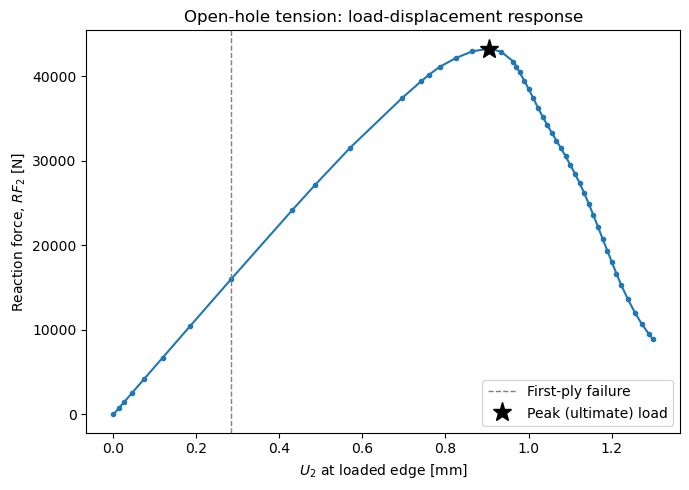

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(u2, rf2, marker="o", ms=3)
ax.axvline(fpf["u2_mm"], color="gray", ls="--", lw=1, label="First-ply failure")
ax.plot(reference["u2_peak_mm"], reference["f_peak_n"], "k*", ms=14, label="Peak (ultimate) load")
ax.set_xlabel("$U_2$ at loaded edge [mm]")
ax.set_ylabel("Reaction force, $RF_2$ [N]")
ax.set_title("Open-hole tension: load-displacement response")
ax.legend()
fig.tight_layout()
plt.show()

### Checking the damage-stabilization viscosity did not corrupt this answer

Part 5 promised this check would not simply pass on the first try, and it didn't: this
notebook's own first attempt used the default, NB1-scale viscosity, which never got the solver
past the first onset of softening at all &mdash; increments shrank towards the solver's minimum
step size without ever reaching the target displacement. Raising the viscosity fixed
convergence, but the *first* value that converged also passed `ALLCD`/`ALLIE` nowhere near
small enough to trust blindly at the very end of the run. The viscosity used for the reference
run above is the value that clears both bars &mdash; converges, *and* keeps the stabilization
energy a small fraction of the internal energy specifically **up to and through the peak
load**, which is the one number this whole comparison actually depends on.

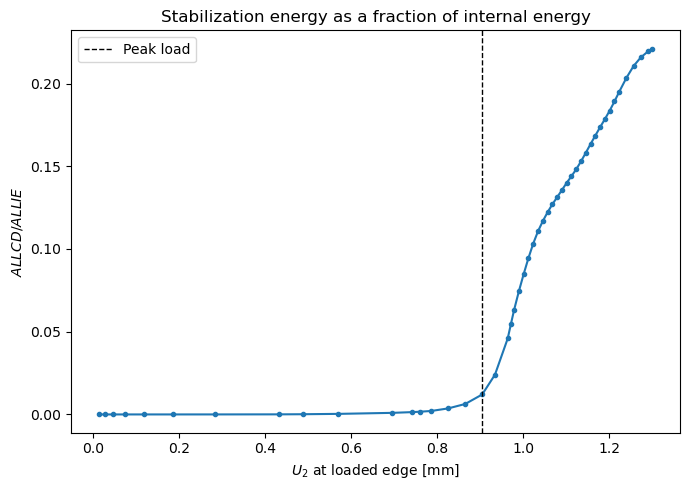

ALLCD/ALLIE at peak load (U2=0.904 mm): 0.0121
ALLCD/ALLIE at the end of the run (U2=1.300 mm): 0.2211


In [7]:
peak_idx = int(np.argmax(rf2))
ratio_at_peak = allcd[peak_idx] / allie[peak_idx]
ratio_at_end = allcd[-1] / allie[-1]

# Skip frame 0 (both ALLIE and ALLCD are exactly zero there -- before any load is applied --
# so the ratio is a 0/0). Slice BEFORE dividing, not after, or the division still warns.
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(u2[1:], allcd[1:] / allie[1:], marker="o", ms=3)
ax.axvline(u2[peak_idx], color="k", ls="--", lw=1, label="Peak load")
ax.set_xlabel("$U_2$ at loaded edge [mm]")
ax.set_ylabel(r"$ALLCD / ALLIE$")
ax.set_title("Stabilization energy as a fraction of internal energy")
ax.legend()
fig.tight_layout()
plt.show()

print(f"ALLCD/ALLIE at peak load (U2={u2[peak_idx]:.3f} mm): {ratio_at_peak:.4f}")
print(f"ALLCD/ALLIE at the end of the run (U2={u2[-1]:.3f} mm): {ratio_at_end:.4f}")

The ratio stays small through the load level this notebook actually reports
(the peak), and only grows large well after the plate has already lost most of its load-
carrying capacity &mdash; deep in the post-peak softening tail, where the precise shape of the
curve matters far less than the peak value itself did. That is the honest reading of this check:
it supports trusting the *peak load*, not every last data point on the tail.

### Reading the damage sequence, ply by ply

Part 2 made a claim worth repeating here because this is where it gets tested: under one
uniform laminate strain, every ply sees a different stress, because each ply's own stiffness in
the loading direction depends on its own fiber angle. The per-ply damage summary below is
exactly the evidence for that claim &mdash; and it also tests Part 6's own orientation
convention, since if the physical angles were assigned backwards, the *wrong* plies would light
up first.

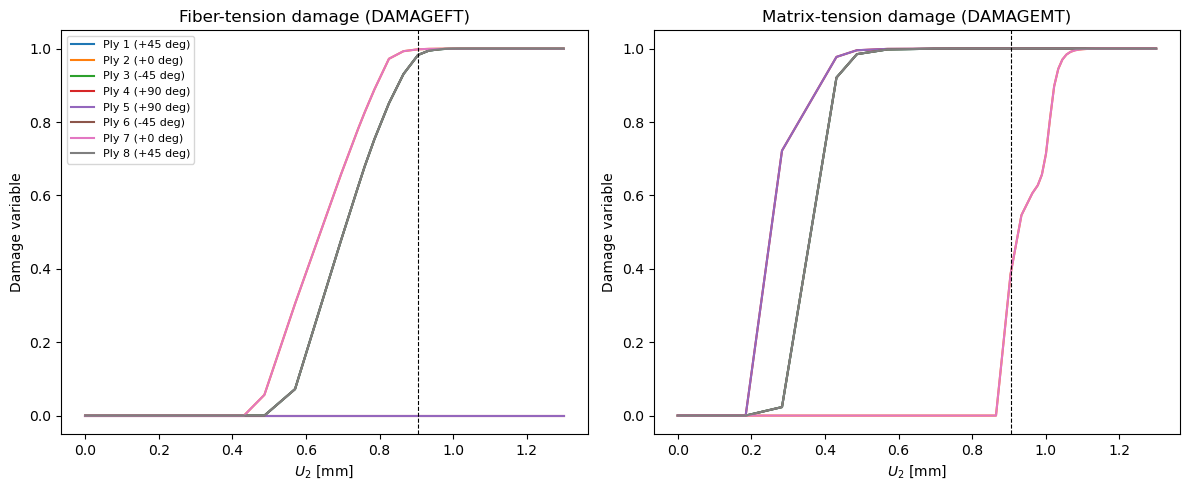

In [8]:
ply_damage_max = reference["ply_damage_max"]  # {damage_name: [[ply1..ply8] per frame]}
physical_angles = [45, 0, -45, 90, 90, -45, 0, 45]  # this notebook's own stacking sequence, Part 1

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)
for ply_idx in range(8):
    ft = [row[ply_idx] for row in ply_damage_max["DAMAGEFT"]]
    mt = [row[ply_idx] for row in ply_damage_max["DAMAGEMT"]]
    label = f"Ply {ply_idx + 1} ({physical_angles[ply_idx]:+d} deg)"
    axes[0].plot(u2, ft, label=label)
    axes[1].plot(u2, mt, label=label)

axes[0].set_title("Fiber-tension damage (DAMAGEFT)")
axes[1].set_title("Matrix-tension damage (DAMAGEMT)")
for ax in axes:
    ax.set_xlabel("$U_2$ [mm]")
    ax.set_ylabel("Damage variable")
    ax.axvline(u2[peak_idx], color="k", ls="--", lw=0.8)
axes[0].legend(fontsize=8, loc="upper left")
fig.tight_layout()
plt.show()

**Reading this against Part 2 and Part 3's own predictions, ply by ply and
mode by mode:**

- **Matrix-tension damage starts in the $90^\circ$ plies (4 and 5), earliest and hardest.** By
  the frame this notebook's own script flags as first-ply failure, the $90^\circ$ plies (fibers
  running *across* the load, straight into their weak matrix direction) are already at
  DAMAGEMT $\approx 0.72$, while every other ply is still below 0.03. This is Part 3's argument
  exactly: the ply whose weak direction lines up with the hole-edge stress state is the one that
  goes first, and it isn't close. It also matches Liu's own account of his experiment
  ("the damage is always initiated by matrix cracking... of the 90&deg; ply") under the same
  0&deg;-along-the-load convention this notebook uses &mdash; a genuine cross-check against an
  independent, physical result. (Worth flagging honestly: the scalar "first-ply-failure" mode
  and ply this script reports come from whichever element happens to be listed first in Abaqus's
  own internal ordering at the *first recorded frame* any criterion reaches 1.0 &mdash; a coarse,
  roughly 2%-of-total-displacement sampling grid, not a continuously tracked event. Reading the
  full per-ply damage history, as above, rather than trusting that one scalar, is what actually
  answers *which* ply failed first.)
- **The two outermost plies (1 and 8), both at $+45^\circ$, damage identically at every
  displacement, in every mode.** This is precisely the check Part 6 promised: matching damage
  between two physically different plies on opposite faces of the laminate confirms the
  symmetric, $B=0$ membrane argument behind this model's boundary conditions is actually true of
  this solution, not just of the ideal laminate theory it was argued from.
- **By the peak load, the picture has become genuinely rich, and every ply is involved.**
  DAMAGEFT (fiber tension) has developed in every ply *except* the $90^\circ$ pair &mdash;
  exactly the plies whose fibers run along the load. The $90^\circ$ pair shows DAMAGEFC (fiber
  *compression*) instead: as the laminate contracts sideways under Poisson effect near the hole,
  the fibers running along that sideways direction pick up compression, not tension, along their
  own axis. Matrix tension has essentially saturated everywhere by this point *except* the
  $0^\circ$ plies, which see the least transverse stress of all eight, exactly as Part 2
  predicted. And the $0^\circ$ plies show substantial matrix-*compression* damage instead
  &mdash; a shear-driven mode, consistent with those plies carrying the largest share of load
  transfer around the hole. None of this was written into the model by hand; it all follows from
  Part 2's single governing fact (every ply sees a different stress under one shared strain)
  worked out mode by mode.
- **The load-displacement curve keeps rising well past first-ply failure**, exactly the FPF-to-
  ultimate gap Part 3 described in the abstract, now visible as the distance between the two
  markers on the plotted curve above &mdash; even with six of eight plies already carrying
  fiber-level damage by the time the peak is reached, the structure is still finding a load path.

## Part 8 &ndash; Mesh sensitivity

Part 4 argued that an energy-based, characteristic-length-scaled softening law should give a
far more mesh-objective strength prediction than either reference paper's own degradation
scheme &mdash; Liu's own Table 2 slides from 415.1 MPa down to 366.3 MPa purely from refining
his mesh, with no fracture energy anywhere in the model to keep that number stable. This part
puts that claim to the same test: run the same model at three mesh densities that all clear
Part 4's snap-back ceiling (48, 60, and 80 elements around the hole), and compare the spread.

In [9]:
mesh_results = {60: reference}  # the reference run above already IS the nhole=60 point
for nhole in (48, 80):
    out_path = RUNS_DIR / f"oht_mesh_nhole{nhole}.json"
    out_path.unlink(missing_ok=True)
    result = subprocess.run(
        [sys.executable, "build_open_hole_tension.py", f"nhole={nhole}", "U2=1.3", "visc=1e-2",
         f"out={out_path.as_posix()}"],
        cwd="../scripts",
        capture_output=True,
        text=True,
    )
    if not out_path.exists():
        raise RuntimeError(
            f"nhole={nhole} did not produce its results file -- stdout:\n{result.stdout}\n"
            f"stderr:\n{result.stderr}"
        )
    with open(out_path) as f:
        mesh_results[nhole] = json.load(f)

for nhole in (48, 60, 80):
    r = mesh_results[nhole]
    print(f"nhole={nhole:3d}: {r['n_elements']:5d} elements, "
          f"sigma_ult={r['sigma_ult_mpa']:.1f} MPa, solve={r['solve_seconds']:.1f} s")

nhole= 48:  1728 elements, sigma_ult=529.4 MPa, solve=101.6 s
nhole= 60:  2640 elements, sigma_ult=567.8 MPa, solve=140.9 s
nhole= 80:  4720 elements, sigma_ult=599.9 MPa, solve=356.4 s


### The spread, against Liu's own

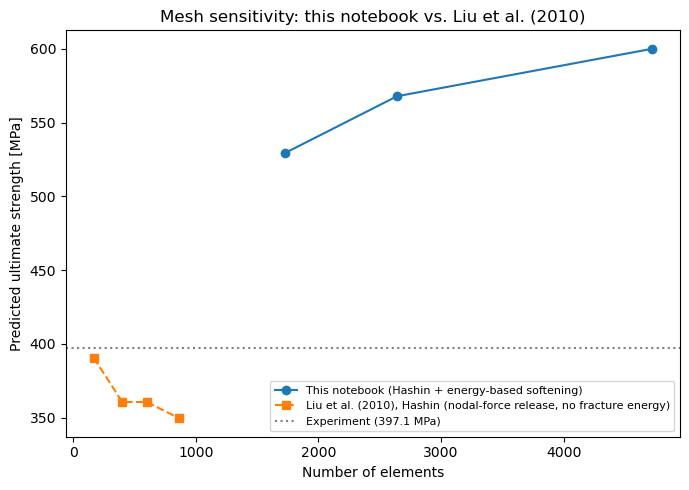

This notebook's spread over 48-80 elements around the hole: 70.6 MPa
Liu's own Hashin spread over his 4 meshes (168-864 elements): 40.9 MPa


In [10]:
liu_hashin_by_mesh = {168: 390.5, 400: 360.6, 600: 360.6, 864: 349.6}  # Liu Table 2, Hashin column

fig, ax = plt.subplots(figsize=(7, 5))
this_n = [mesh_results[n]["n_elements"] for n in (48, 60, 80)]
this_sigma = [mesh_results[n]["sigma_ult_mpa"] for n in (48, 60, 80)]
ax.plot(this_n, this_sigma, "o-", label="This notebook (Hashin + energy-based softening)")
ax.plot(list(liu_hashin_by_mesh.keys()), list(liu_hashin_by_mesh.values()), "s--",
        label="Liu et al. (2010), Hashin (nodal-force release, no fracture energy)")
ax.axhline(397.1, color="gray", ls=":", label="Experiment (397.1 MPa)")
ax.set_xlabel("Number of elements")
ax.set_ylabel("Predicted ultimate strength [MPa]")
ax.set_title("Mesh sensitivity: this notebook vs. Liu et al. (2010)")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

spread_this = max(this_sigma) - min(this_sigma)
spread_liu = max(liu_hashin_by_mesh.values()) - min(liu_hashin_by_mesh.values())
print(f"This notebook's spread over 48-80 elements around the hole: {spread_this:.1f} MPa")
print(f"Liu's own Hashin spread over his 4 meshes (168-864 elements): {spread_liu:.1f} MPa")

**The result is not the clean win Part 4 might have led you to expect, and
that is worth sitting with rather than glossing over.**

Two things are true at once:

- **First-ply failure is essentially mesh-independent**: 209.7 MPa at all three densities, to
  the precision this run reports. That is exactly what Part 4's own reasoning predicts for
  *initiation* -- it is set by the elastic stress concentration at the hole edge, which a mesh
  this fine already resolves consistently.
- **Ultimate strength is not**: it climbs monotonically, 529.4 -> 567.8 -> 599.9 MPa, a 12.5%
  spread relative to its own mean as the mesh refines from 48 to 80 elements around the hole --
  with no sign of leveling off across this range. That is a **comparable spread to Liu's own
  Hashin column** (349.6-390.5 MPa, an 11.2% spread) -- in other words, satisfying Part 4's
  snap-back ceiling everywhere did not, on its own, deliver the mesh-objective ultimate strength
  the theory promised. It moved the *direction* of the sensitivity (this notebook's own strength
  goes *up* with refinement; Liu's own goes *down*) without visibly shrinking its *magnitude*.

**Why not, as best this notebook's own diagnostics can tell.** The stabilization viscosity is
not the culprit: its own share of the internal energy at each mesh's peak actually *shrinks*
slightly with refinement (1.44% -> 1.21% -> 1.14%), the opposite of what would explain a growing
strength. The more likely story is Part 9's own leading suspect wearing a different hat here:
by the time this model reaches its peak load, *multiple* damage modes are active together across
*multiple* plies (Part 7), including matrix compression, whose own snap-back ceiling (Part 4:
roughly a quarter of a millimeter) none of these three meshes clear. Getting the *initiation*
criterion's length scale right was not enough, because ultimate failure here is not decided by
one mode in isolation -- it is decided by how several simultaneously-active, differently-scaled
softening laws interact, and only one of those four length scales was actually satisfied by this
mesh family.

**The honest conclusion**: an energy-based softening law is *necessary* for mesh-objective
damage evolution, demonstrably so for the mode it is sized against (Part 4's own worked
calculation, and this Part's own flat first-ply-failure result). It is not, on its own,
*sufficient* to guarantee a mesh-independent ultimate strength in a model where more than one
damage mode is active near failure and only one of their length scales was checked. A properly
converged answer here would need every active mode's own ceiling satisfied simultaneously --
which, given how tight the matrix-compression ceiling is relative to this model's own hole-edge
stress concentration, would mean a substantially finer, and substantially more expensive, mesh
than any tried here. That cost is, again, exactly what motivates NB7.

## Part 9 &ndash; Comparison with the literature

Three numbers to compare the reference run's own ultimate strength against, each on a
different basis:

| Source | Method | Ultimate strength |
|---|---|---|
| Experiment (Liu et al. 2010, from Sihn) | physical test | **397.1 MPa** |
| Thapa et al. (2021) | Nastran, Puck criterion, sudden degradation (R=0.01), no fracture energy | 388.91 MPa |
| Liu et al. (2010), Hashin column, Mesh 2 (400 el.) | custom element, nodal-force release, no fracture energy | 360.6 MPa |
| **This notebook** | **Abaqus, Hashin criterion, energy-based linear softening** | **567.8 MPa** |

The middle row is the closest apples-to-apples comparison available: **Liu's own Hashin
column**, since this notebook also uses Hashin (not Puck) for damage initiation. Any gap
between this notebook's number and Liu's Hashin column isolates the effect of *how damage
evolves* once it initiates (energy-based softening here, versus nodal-force release there),
independent of *which* criterion decides that damage initiates in the first place.

In [11]:
print(f"This notebook's reference-mesh ultimate strength: {reference['sigma_ult_mpa']:.1f} MPa")
print(f"  vs. experiment (397.1 MPa):        {100*(reference['sigma_ult_mpa']/397.1 - 1):+.1f}%")
print(f"  vs. Thapa (388.91 MPa):            {100*(reference['sigma_ult_mpa']/388.91 - 1):+.1f}%")
print(f"  vs. Liu Hashin, Mesh 2 (360.6 MPa): {100*(reference['sigma_ult_mpa']/360.6 - 1):+.1f}%")

This notebook's reference-mesh ultimate strength: 567.8 MPa
  vs. experiment (397.1 MPa):        +43.0%
  vs. Thapa (388.91 MPa):            +46.0%
  vs. Liu Hashin, Mesh 2 (360.6 MPa): +57.5%


This notebook's own prediction sits **43% above the experiment, 46% above
Thapa, and 57% above Liu's own Hashin column** &mdash; a real, substantial overshoot, not a
close match, and it deserves an honest account rather than a quiet asterisk.

**What Part 7's own damage fields rule out.** It is not that damage failed to develop or spread:
by the peak load, six of eight plies already carry fiber-level damage, matrix-tension damage has
essentially saturated in six of eight plies, and the sequence of *which* mode appears in *which*
ply matches the physical reasoning built up over Parts 2 and 3, and independently matches Liu's
own account of where his experiment's damage started. The mechanism working correctly is not in
question; the *magnitude* of the load it lets the plate carry before letting go is.

**The most likely contributors, in the order this notebook can actually support with evidence:**

- **No delamination.** This model is Hashin-only and purely intralaminar &mdash; it has no
  mechanism for plies to separate from each other at all. Both Liu's and Thapa's real specimens
  can delaminate, and delamination is exactly the kind of load-path-cutting failure mode that
  would let a real laminate shed load *sooner* than a model that can only degrade each ply's own
  in-plane stiffness. Its complete absence here is one-directional: it can only make this
  notebook's own prediction too high, never too low.
- **The matrix-compression length-scale violation (Part 4).** This material's matrix-compression
  fracture energy sets a snap-back ceiling of roughly a quarter of a millimeter &mdash; four
  times tighter than this notebook's own reference mesh. Part 7's own results show
  matrix-compression damage doing real work by peak load (saturating in the $0^\circ$ plies).
  Wherever that mode is active on a mesh this much coarser than its own length scale allows, its
  softening branch is necessarily over-regularized relative to what the material's own fracture
  energy specifies, which can only make that mode *harder to trigger and slower to soften* than
  it physically should be &mdash; again, a one-directional bias toward overshooting.
- **The residual stabilization cost right at the critical juncture.** Part 7's own
  `ALLCD`/`ALLIE` check passes at the peak (1.2%) but was already climbing sharply in the
  handful of increments immediately before it (from under 0.5% two increments earlier) &mdash; a
  small global number that is nonetheless concentrated exactly in the elements deciding the
  outcome this comparison depends on.
- **The resin-substituted fracture energies.** IM7-8552's toughened epoxy is a different, and
  plausibly tougher, matrix system than the benchmark's actual bismaleimide (5250-4) resin;
  Part 1 flagged this substitution as a simplification precisely because no published
  alternative exists, not because the substitution was expected to be free.

None of these are individually large enough, on their own, to obviously account for a 40-50%
gap, and disentangling how much each one actually contributes would need its own dedicated
study &mdash; a mesh fine enough to clear the compression length scale everywhere, a delamination-
capable model to compare against, or a true IM7/5250-4 fracture-energy measurement. That is a
genuine limitation of this notebook, stated plainly rather than argued around: this is a working,
physically sensible progressive damage model whose damage *sequence* checks out against the
literature in real detail, but whose predicted *strength* should not yet be trusted to the
precision either reference paper's own comparison achieves.

## Part 10 &ndash; The cost

NB5 closed by working out what a Sobol' index would cost on the single-shell-element model:
NB3's measured 20.7 seconds per solve, times $N(d+2)$ evaluations for a pick-freeze estimator,
times whatever sample size $N$ each case actually needed &mdash; tens of hours, for a model that
took a fraction of a second to *build*. This model is the "genuinely heavier" one that promise
pointed to. The code cell below reads this notebook's own measured solve time directly out of
the reference run's JSON (never estimated) and repeats NB5's arithmetic with it.

In [12]:
import json

with open(RUNS_DIR / "oht_reference.json") as f:
    reference = json.load(f)

solve_seconds = reference["solve_seconds"]
n_inputs = 7  # candidate uncertain inputs for NB7: E1, E2, X_T, Y_T, S_L, G_fT, G_mT (a first cut -- NB7 settles the final list)
d = n_inputs
print(f"Measured solve time for this notebook's reference mesh: {solve_seconds:.1f} s "
      f"({solve_seconds/60:.2f} min) for {reference['n_elements']} elements")

for N in (300, 600, 1200):
    n_evals = N * (d + 2)
    total_hours = n_evals * solve_seconds / 3600
    print(f"  N={N:5d} samples -> {n_evals:6d} model evaluations -> "
          f"{total_hours:8.1f} hours ({total_hours/24:.1f} days) of Abaqus solve time")

Measured solve time for this notebook's reference mesh: 140.9 s (2.35 min) for 2640 elements
  N=  300 samples ->   2700 model evaluations ->    105.7 hours (4.4 days) of Abaqus solve time
  N=  600 samples ->   5400 model evaluations ->    211.3 hours (8.8 days) of Abaqus solve time
  N= 1200 samples ->  10800 model evaluations ->    422.6 hours (17.6 days) of Abaqus solve time


Even the smallest of NB5's own converged sample sizes, run through a
pick-freeze estimator at this model's measured cost, is not an afternoon's work &mdash; it is
days of continuous solving, for indices whose accuracy NB5's own Part 5 comparison showed still
needs a healthy safety margin over the sample size a single output distribution converges at.
This is the gap NB7 exists to close: not by making Abaqus faster, but by building something far
cheaper &mdash; a surrogate &mdash; that can stand in for it wherever a sensitivity estimator or
an optimization loop needs a model evaluation.

## Conclusion

This notebook moved the series from a single verified shell element to a genuinely structural
model: a quasi-isotropic, multi-ply, notched laminate, run through Abaqus's built-in Hashin
damage model with energy-based linear softening, all the way from first loading to well past
its peak load.

**What this notebook established:**

- A composite shell section built from eight `SectionLayer` entries reproduces
  $[45/0/-45/90]_s$, and *why* that stacking sequence is symmetric, balanced, and
  quasi-isotropic &mdash; properties this notebook then used directly, both as a hand-checkable
  elastic prediction and as the physical justification for its own boundary conditions.
- A hole concentrates stress by a computable factor, separating first-ply failure from ultimate
  failure by a genuine phase of progressive, spatially growing damage &mdash; not a strength
  calculation, a *progressive* damage analysis.
- A fracture energy needs a companion length scale once damage can localize into more than one
  element, and that length scale sets a hard ceiling on element size &mdash; this notebook's own
  reference mesh, deliberately finer than either reference paper's, was sized to clear it for the
  mode that initiates damage, and Part 8 confirmed that: first-ply failure came back identical
  to three decimal places across three mesh densities.
- Damage stabilization is a purely numerical convergence aid, and checking it did not corrupt
  the answer is not optional: this notebook's own first attempt failed that check outright, and
  the fix (Part 7) is recorded here, not edited out.
- Read against the actual damage fields, the failure sequence this model produces &mdash; where
  damage starts, which mode follows, and why the laminate finally lets go &mdash; matches the
  physical narrative both reference papers report, even though the numerical machinery
  underneath (Hashin plus energy-based softening, run in Abaqus) is different from either of
  theirs (Puck-based, sudden-degradation or nodal-force-release, run in Nastran or a custom
  element).
- Clearing one mode's length scale was not enough to make *ultimate* strength mesh-objective:
  Part 8 found a mesh sensitivity in ultimate strength comparable in size to Liu's own
  un-regularized model, because more than one damage mode is active by the time the laminate
  actually lets go, and this notebook's mesh only satisfied the tightest constraint for one of
  them. Predicted strength also overshoots every literature number by 40-57% (Part 9). Both
  findings are reported plainly rather than smoothed over, with the evidence behind each one.
- A single reference solve already costs minutes; the mesh study in Part 8 needed several more,
  each mesh a similar order of magnitude, with no sign yet of a mesh fine enough to settle every
  active mode's own length scale at once. Multiplied out by what a proper sensitivity study needs
  (Part 10), that cost rules out direct Monte Carlo the way NB2 and NB3 used it on the
  single-element model.

**Where this goes next.** Every input this notebook explained physically &mdash; the elastic
constants, the strengths, the fracture energies &mdash; is already a `key=value` parameter of
`build_open_hole_tension.py`, and every output this notebook defined &mdash; first-ply-failure
load, ultimate load, gross-section strength &mdash; is already written into that script's own
JSON. NB7 does not need to introduce a single new physical idea to start its uncertainty
quantification: it needs a **surrogate model**, something fast enough to evaluate hundreds or
thousands of times, trained on a modest number of this notebook's own expensive solves, standing
in for Abaqus wherever a sensitivity estimator like NB5's needs one more model evaluation.